# 7. Are the rules robust? Stability and statistical validation

A genetic search returns one of many good rule bases. Before trusting a
rule as an insight about the data, two questions are worth asking: does it
come back when the search is repeated, and is it better than chance?
Ex-Fuzzy answers the first with **pattern stability** reports over many
fits, and the second with **permutation and bootstrap tests** on a fitted
model.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from ex_fuzzy import BaseFuzzyRulesClassifier, fuzzy_sets as fs, pattern_stability, utils

iris = load_iris(as_frame=True)
X = iris.frame.drop(columns='target')
y = iris.target_names[iris.target]
partitions = utils.construct_partitions(X, fs.FUZZY_SETS.t1)

## Pattern stability across repeated fits

`pattern_stabilizer` refits the classifier many times on random train/test
splits and counts how often each antecedent pattern, and each variable, is
used per class. Patterns that appear in most fits are stable findings;
patterns that appear once are artefacts of one search.

In [2]:
stabilizer = pattern_stability.pattern_stabilizer(X, y, nRules=8, nAnts=3, linguistic_variables=partitions,
                                                   class_names=list(iris.target_names))
report = stabilizer.stability_report(n=12, n_gen=20, pop_size=20)

Pattern stability report for 12 generated solutions
Average accuracy: 0.89\pm0.07
-------------
Class setosa
Number of unique patterns: 12
Pattern IF sepal width (cm) IS High AND petal width (cm) IS Low appears in 0% of the trials with a Dominance Score of 0.18645833333333334
Pattern IF sepal length (cm) IS Medium AND petal length (cm) IS Medium appears in 0% of the trials with a Dominance Score of 8.683471887650682e-06
Pattern IF petal width (cm) IS Low appears in 0% of the trials with a Dominance Score of 0.29449793046357614
Pattern IF sepal width (cm) IS High AND petal length (cm) IS Medium AND petal width (cm) IS Low appears in 0% of the trials with a Dominance Score of 0.004913194444444444
Pattern IF petal length (cm) IS Low appears in 0% of the trials with a Dominance Score of 0.32531375502008025

Variable sepal length (cm)
Medium appears 0.75 times per experiment.
Low appears 0.08 times per experiment.

Variable sepal width (cm)
High appears 0.75 times per experiment.
Medium app

The pie charts show, per class, which labels of a variable the rules use
across the repeated fits.

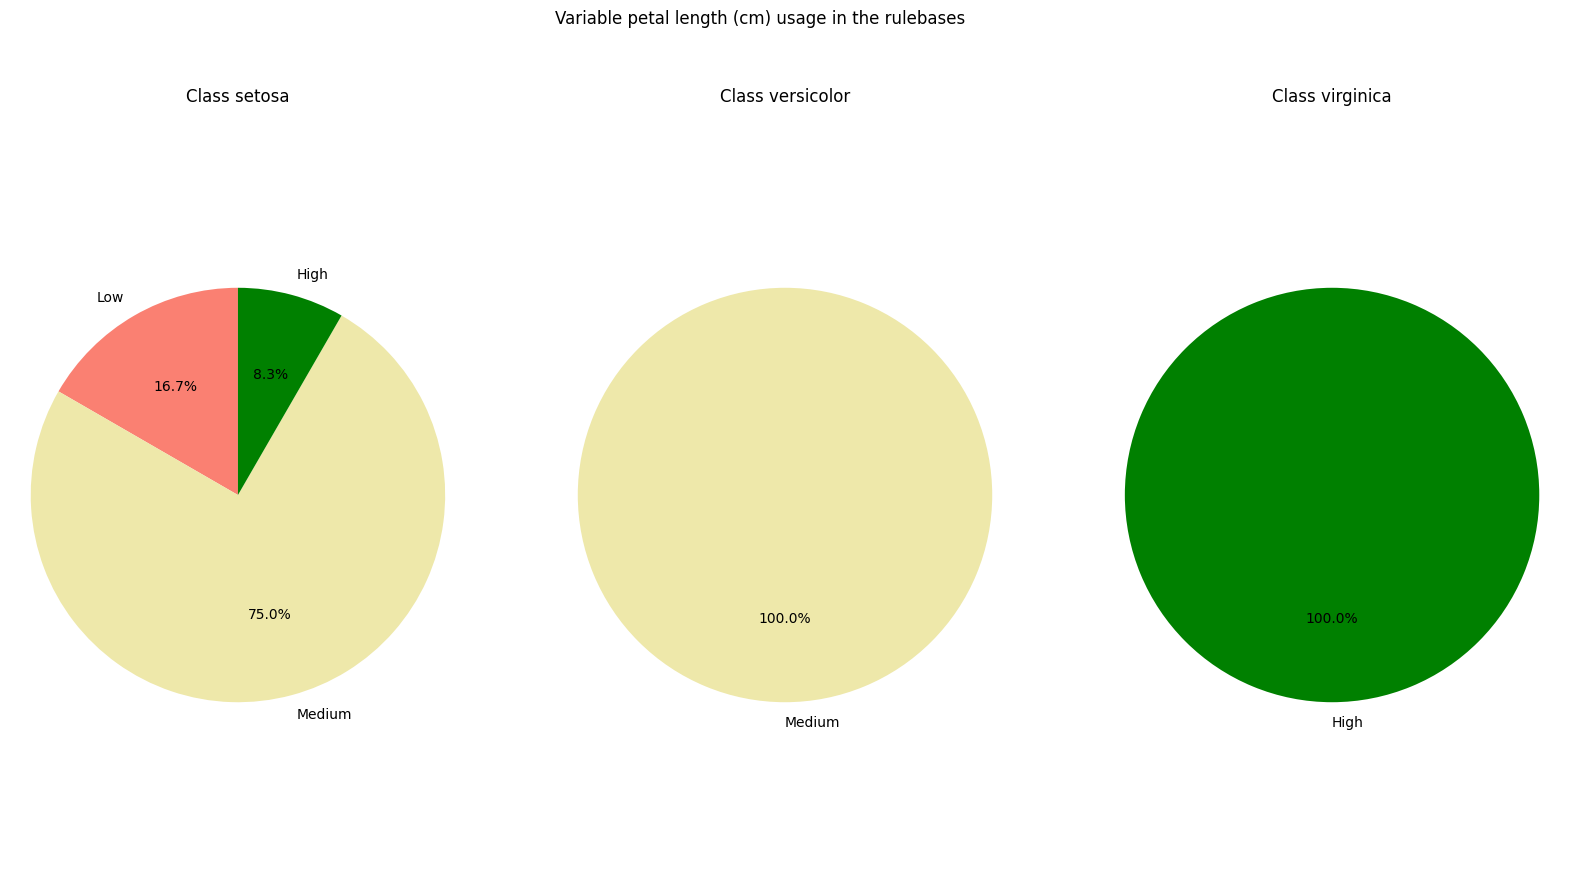

In [3]:
stabilizer.pie_chart_var(2)      # petal length, per class

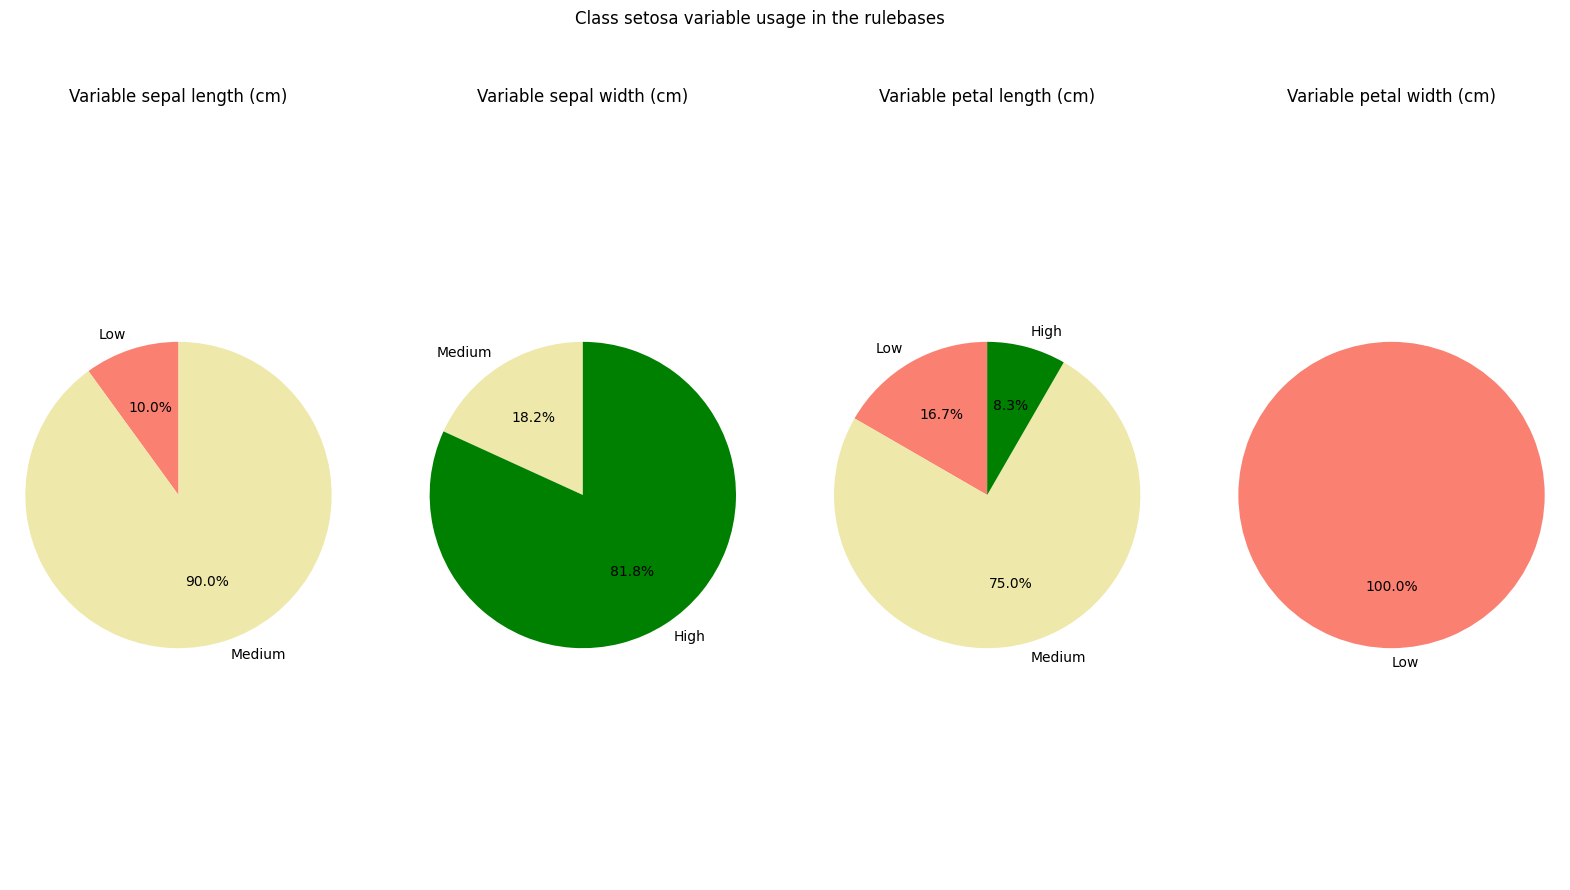

In [4]:
stabilizer.pie_chart_class(0)    # setosa, per variable

## Statistical validation of one model

`fit(..., p_value_compute=True)` runs three tests on the fitted rule base:

- **class structure**: labels are permuted; if the rule base still scores as
  well, it did not learn the classes;
- **feature coalition**: columns are permuted within each class, breaking
  the joint patterns rules rely on;
- **membership validation**: bootstrap resampling of the data, giving
  confidence intervals for each rule's support and confidence.

The results are printed with the rules: stars for the p-values and the
bootstrap intervals for the two statistics.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0, stratify=y)
validated = BaseFuzzyRulesClassifier(nRules=8, nAnts=3, linguistic_variables=partitions, n_gen=30, pop_size=30, random_state=0)
validated.fit(X_train, y_train, p_value_compute=True, bootstrap_size=200)
print(f'test accuracy: {validated.score(X_test, y_test):.3f}')
print(f'p-value, class structure:   {validated.p_value_class_structure:.3f}')
print(f'p-value, feature coalition: {validated.p_value_feature_coalitions:.3f}')

test accuracy: 0.860
p-value, class structure:   0.010
p-value, feature coalition: 0.010


In [6]:
validated.print_rules(bootstrap_results=True)

Rules for consequent: setosa
----------------
IF petal length (cm) IS Low WITH DS 0.3136333333333334, ACC 0.9428571428571428 (p-value Permutation Class Structure: **, Feature Coalition: ** Membership Validation: ***) Confidence Interval: [0.93597621 0.99016305] Support Interval: [0.23247917 0.39717708]

Rules for consequent: versicolor
----------------
IF petal length (cm) IS Medium AND petal width (cm) IS Medium WITH DS 0.2632906103859396, ACC 0.8461538461538461 (p-value Permutation Class Structure: **, Feature Coalition: ns Membership Validation: **) Confidence Interval: [0.87098487 0.98069595] Support Interval: [0.20870762 0.3663109 ]

Rules for consequent: virginica
----------------
IF sepal length (cm) IS High AND petal length (cm) IS High WITH DS 0.2199075017994403, ACC 1.0 (p-value Permutation Class Structure: **, Feature Coalition: ** Membership Validation: *) Confidence Interval: [0.90010388 0.99791056] Support Interval: [0.16544853 0.29887955]




A rule whose support interval starts near zero fires rarely; a wide
confidence interval means its precision depends on which samples happen to
be in the data. Both are reasons to prefer another rule with the same
accuracy.